# Занятие 32. Практика: решающее дерево — лаборатория стабильности

Вы пишете код в ячейках заданий. Блоки **«Легенда»** и **«Дано»** не меняйте.

Главная модель — **DecisionTreeClassifier** (решающее дерево). Теория — занятие 31, ноутбук `Урок_31_Решающее_дерево.ipynb`.

Это **не** классическое «обучи и побей accuracy». Главный вопрос практики: **насколько нервно** дерево меняет ответы, если validation слегка «подёргать» шумом. Accuracy рядом — как справочная метрика.

### Оценивание (30 баллов)

| № | Тема | Баллы |
|---|------|------:|
| 1 | Split и импорты | 2 |
| 2 | Глубокое и ограниченное дерево | 4 |
| 3 | Протокол flip-rate (шум на X_val) | 5 |
| 4 | Кривая flip-rate vs сила шума | 5 |
| 5 | Bar-сравнение deep vs shallow | 3 |
| 6 | `plot_tree` устойчивого варианта | 3 |
| 7 | `ccp_alpha` через стабильность | 4 |
| 8 | Confusion matrix (доп. взгляд) | 2 |
| 9 | Итог: почему глубокое «нервное» | 2 |
| | **Итого** | **30** |


---
## Легенда: камера «ЖестStop» lite

В городе тестируют **учебный** прототип камеры на пешеходном переходе.
Камера смотрит на человека у края дороги и решает: **поднял ли он руку** (жест «хочу перейти») или **нет**.

Это учебный сценарий: данные **синтетические**, штрафы настоящие не выписываем.

### Признаки (таблица)

| Признак | Смысл |
|---------|--------|
| `hand_height` | насколько высоко «рука» относительно плеча |
| `arm_angle` | угол руки |
| `motion_speed` | скорость движения в кадре |
| `brightness` | яркость кадра |
| `edge_contrast` | контраст границ |
| `shadow_noise` | шум теней (часто мешает) |
| `frame_blur` | размытие кадра |
| `sensor_jitter` | дрожание сенсора (почти бесполезный шум) |

### Метка

| Значение | Смысл |
|----------|--------|
| `1` | жест «рука вверх» (хочу перейти) |
| `0` | жеста нет |

### Зачем лаборатория стабильности?

На улице признаки чуть «пляшут»: облако, блик, тряска камеры.
Если дерево из‑за мелкого шума **часто меняет ответ**, камера будет «дёргаться»: то жест есть, то нет.
Поэтому главная метрика занятия — **flip-rate** (доля объектов validation, у которых предсказание **сменилось** после шума), а не гонка за accuracy.

### Протокол (держимся его во всей практике)

1. Обучаем модели **один раз** на чистом train.
2. На **тех же** моделях берём `X_val` и добавляем **гауссов шум** разной силы (`noise_std`).
3. Считаем, какая **доля** объектов сменила предсказание относительно ответа на чистом `X_val`.
4. Модель **не** переобучаем на шуме — честно проверяем нервозность границ.

### Короткий словарь

| Слово | Значение |
|-------|----------|
| **признак** | одно число в таблице (например, `hand_height`) |
| **метка / класс** | правильный ответ: жест есть или нет |
| **train** | кадры, на которых дерево **учится** |
| **validation** | кадры для **сравнения** настроек и стабильности |
| **глубокое дерево** | почти без ограничений (`max_depth=None`) — много мелких правил |
| **ограниченное дерево** | `max_depth` и/или `min_samples_leaf` — простые правила |
| **flip-rate** | доля объектов val, у которых прогноз **изменился** после шума |
| **accuracy** | доля верных ответов (здесь — справочно) |
| **`ccp_alpha`** | сила обрезки дерева после обучения |


---
## Дано: синтетические кадры «ЖестStop»

Ячейку ниже **не меняйте**. Она создаёт таблицу признаков `X`, метки `y`, имена `FEATURE_NAMES` / `CLASS_NAMES` и фиксирует `RANDOM_STATE`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

RANDOM_STATE = 42

X, y = make_classification(
    n_samples=800,
    n_features=8,
    n_informative=3,
    n_redundant=2,
    n_repeated=0,
    n_classes=2,
    n_clusters_per_class=2,
    flip_y=0.05,
    class_sep=1.2,
    random_state=RANDOM_STATE,
)

FEATURE_NAMES = [
    'hand_height',
    'arm_angle',
    'motion_speed',
    'brightness',
    'edge_contrast',
    'shadow_noise',
    'frame_blur',
    'sensor_jitter',
]
CLASS_NAMES = ['жеста нет', 'рука вверх']

print('Кадров:', len(X))
print('Классы [жеста нет, рука вверх]:', np.bincount(y))
pd.DataFrame(X, columns=FEATURE_NAMES).head(3)


Кадров: 800
Классы [жеста нет, рука вверх]: [404 396]


,hand_height,arm_angle,motion_speed,brightness,edge_contrast,shadow_noise,frame_blur,sensor_jitter
0,0.817365,-1.999246,0.961987,-0.042433,1.102953,0.749900,-2.514472,-0.237012
1,0.428349,1.165172,-2.371659,1.350800,1.532978,0.295280,-1.611274,2.042070
2,-1.169192,1.492849,0.015618,-1.230489,-2.286073,-0.907756,4.310306,0.902277


---
## Задание 1. Split и импорты — **2 балла**

Подготовьте данные для лаборатории.

**Шаг 1.** Задайте `RANDOM_STATE = 42` (если ещё не задан в «Дано» — можно переиспользовать).

**Шаг 2.** Разделите `X`, `y` на train и validation (**70 / 30**, `stratify=y`, `random_state=RANDOM_STATE`).
Сохраните `X_train`, `X_val`, `y_train`, `y_val`.

**Шаг 3.** Выведите размеры выборок.

Импорты уже есть в «Дано» — повторно импортировать не обязательно.

### Подробные критерии (для проверки LLM)

- **1.0 балл** — получены `X_train`, `X_val`, `y_train`, `y_val` с `test_size=0.3` и `random_state=42`.
- **1.0 балл** — использован `stratify=y`; размеры ≈ 560 / 240.

### Снижение баллов

- Нет `stratify` → минус **0.5**.
- Изменён блок «Дано» → минус **1.0**.


In [2]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print('train / val:', len(X_train), len(X_val))
print('доля класса 1 в train:', round(y_train.mean(), 3))
print('доля класса 1 в val:', round(y_val.mean(), 3))


train / val: 560 240
доля класса 1 в train: 0.495
доля класса 1 в val: 0.496


---
## Задание 2. Глубокое и ограниченное дерево — **4 балла**

Обучите **две** модели на одном train.

**Шаг 1.** `tree_deep` — `DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE)`.

**Шаг 2.** `tree_shallow` — `DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=RANDOM_STATE)`.

**Шаг 3.** Для каждой модели выведите:
- глубину (`get_depth()`);
- число листьев (`get_n_leaves()`);
- accuracy на train и на validation.

**Шаг 4.** Коротко (1–2 предложения в `print` или markdown рядом): у какой модели сильнее разрыв train vs validation?

Глубина и листья — из теории занятия 31. Здесь они нужны, чтобы потом связать «сложность» со **стабильностью**.

### Подробные критерии (для проверки LLM)

- **1.0 балл** — обучен `tree_deep` с `max_depth=None`.
- **1.0 балл** — обучен `tree_shallow` с `max_depth=3` и `min_samples_leaf=20`.
- **1.0 балл** — для обеих моделей напечатаны глубина, листья, train/val accuracy.
- **1.0 балл** — есть вывод про разрыв train/val (у глубокого обычно сильнее / train≈1.0).

### Снижение баллов

- Модели обучены не на `X_train` / `y_train` → минус **1.5**.
- Нет сравнения двух моделей → минус **1.0**.


In [3]:
tree_deep = DecisionTreeClassifier(
    max_depth=None, random_state=RANDOM_STATE
).fit(X_train, y_train)

tree_shallow = DecisionTreeClassifier(
    max_depth=3, min_samples_leaf=20, random_state=RANDOM_STATE
).fit(X_train, y_train)

for name, model in [('deep', tree_deep), ('shallow', tree_shallow)]:
    acc_tr = accuracy_score(y_train, model.predict(X_train))
    acc_va = accuracy_score(y_val, model.predict(X_val))
    print(
        f'{name}: depth={model.get_depth()}, leaves={model.get_n_leaves()}, '
        f'train_acc={acc_tr:.3f}, val_acc={acc_va:.3f}'
    )

print(
    'Вывод: глубокое дерево часто запоминает train (accuracy≈1), '
    'а на validation качество близко к ограниченному — разрыв train/val у deep больше.'
)


deep: depth=9, leaves=29, train_acc=1.000, val_acc=0.946
shallow: depth=3, leaves=7, train_acc=0.946, val_acc=0.950
Вывод: глубокое дерево часто запоминает train (accuracy≈1), а на validation качество близко к ограниченному — разрыв train/val у deep больше.


---
## Задание 3. Протокол flip-rate (шум на X_val) — **5 баллов**

Реализуйте функцию стабильности.

```python
def flip_rate(model, X_val, noise_std, n_repeats=20, seed=0) -> float:
    ...
```

**Правила протокола:**

1. `base = model.predict(X_val)` — ответы на **чистом** validation.
2. Повторить `n_repeats` раз:
   - `noisy = X_val + нормальный_шум(mean=0, std=noise_std)` той же формы;
   - `pred = model.predict(noisy)`;
   - доля объектов, где `pred != base`.
3. Вернуть **среднее** этих долей (float).
4. Модель **не** трогать (`fit` внутри функции запрещён).

**Проверка:** для `noise_std=0` flip-rate должен быть **0.0** (у обеих моделей).
Посчитайте flip-rate при `noise_std=0.35` для `tree_deep` и `tree_shallow` и напечатайте.

### Подробные критерии (для проверки LLM)

- **1.5 балла** — функция сравнивает шумные предсказания с `base` на чистом `X_val`.
- **1.0 балл** — шум гауссов, форма как у `X_val`; есть усреднение по `n_repeats`.
- **1.0 балл** — при `noise_std=0` flip-rate = 0 для обеих моделей.
- **1.5 балла** — при `noise_std=0.35` flip-rate deep **больше**, чем shallow (типично ≈ в 1.5–2+ раза).

### Снижение баллов

- Переобучение модели внутри функции → минус **2.0**.
- Шум добавлен к меткам / train вместо `X_val` → минус **2.0**.
- Считается accuracy вместо доли сменившихся предсказаний → минус **1.5**.


In [4]:
def flip_rate(model, X_val, noise_std, n_repeats=20, seed=0):
    """Доля объектов val, у которых прогноз сменился после гауссова шума."""
    rng = np.random.default_rng(seed)
    base = model.predict(X_val)
    rates = []
    for _ in range(n_repeats):
        noisy = X_val + rng.normal(0.0, noise_std, size=X_val.shape)
        pred = model.predict(noisy)
        rates.append(np.mean(pred != base))
    return float(np.mean(rates))


print('flip@0 deep/shallow:', flip_rate(tree_deep, X_val, 0.0), flip_rate(tree_shallow, X_val, 0.0))
print(
    'flip@0.35 deep/shallow:',
    round(flip_rate(tree_deep, X_val, 0.35), 3),
    round(flip_rate(tree_shallow, X_val, 0.35), 3),
)


flip@0 deep/shallow: 0.0 0.0
flip@0.35 deep/shallow: 0.072 0.035


---
## Задание 4. Кривая flip-rate vs сила шума — **5 баллов**

Постройте главную картинку лаборатории.

**Шаг 1.** Возьмите сетку сил шума, например:
`sigmas = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]`.

**Шаг 2.** Для каждого `sigma` посчитайте flip-rate у `tree_deep` и `tree_shallow` (одна и та же функция из задания 3).

**Шаг 3.** На **одном** графике нарисуйте две линии: flip-rate vs `sigma`.
Обязательны: заголовок, подписи осей, легенда.

**Шаг 4.** Справочно напечатайте таблицу: `sigma`, `flip_deep`, `flip_shallow`, `val_acc_deep`, `val_acc_shallow`
(accuracy — на **чистом** `X_val`, она не зависит от `sigma`; это напоминание, что accuracy «стоит рядом»).

### Подробные критерии (для проверки LLM)

- **1.5 балла** — посчитаны ряды flip-rate по сетке `sigmas` для обеих моделей.
- **2.0 балла** — график line: две кривые, заголовок, оси, легенда.
- **1.5 балла** — кривая deep лежит **выше** shallow на средних/больших `sigma`; есть печать чисел.

### Снижение баллов

- Нет легенды или подписей осей → минус **1.0**.
- На графике только accuracy без flip-rate → минус **2.0**.
- Модели переобучаются на каждой силе шума → минус **1.5**.


sigma | flip_deep | flip_shallow | val_acc_deep | val_acc_shallow
 0.00 |     0.000 |        0.000 |        0.946 |          0.950
 0.05 |     0.015 |        0.005 |        0.946 |          0.950
 0.10 |     0.027 |        0.009 |        0.946 |          0.950
 0.20 |     0.052 |        0.021 |        0.946 |          0.950
 0.35 |     0.072 |        0.035 |        0.946 |          0.950
 0.50 |     0.099 |        0.055 |        0.946 |          0.950
 0.75 |     0.143 |        0.096 |        0.946 |          0.950
 1.00 |     0.188 |        0.137 |        0.946 |          0.950


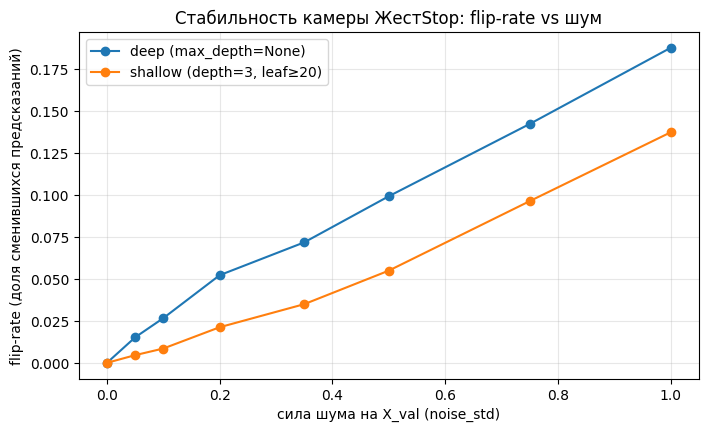

In [5]:
sigmas = [0.0, 0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0]

flip_deep = [flip_rate(tree_deep, X_val, s) for s in sigmas]
flip_shallow = [flip_rate(tree_shallow, X_val, s) for s in sigmas]

acc_deep = accuracy_score(y_val, tree_deep.predict(X_val))
acc_shallow = accuracy_score(y_val, tree_shallow.predict(X_val))

print('sigma | flip_deep | flip_shallow | val_acc_deep | val_acc_shallow')
for s, fd, fs in zip(sigmas, flip_deep, flip_shallow):
    print(f'{s:5.2f} | {fd:9.3f} | {fs:12.3f} | {acc_deep:12.3f} | {acc_shallow:14.3f}')

plt.figure(figsize=(8, 4.5))
plt.plot(sigmas, flip_deep, marker='o', label='deep (max_depth=None)')
plt.plot(sigmas, flip_shallow, marker='o', label='shallow (depth=3, leaf≥20)')
plt.xlabel('сила шума на X_val (noise_std)')
plt.ylabel('flip-rate (доля сменившихся предсказаний)')
plt.title('Стабильность камеры ЖестStop: flip-rate vs шум')
plt.grid(alpha=0.3)
plt.legend()
plt.show()


---
## Задание 5. Bar-сравнение deep vs shallow — **3 балла**

Зафиксируйте одну «уличную» силу шума: `NOISE_COMPARE = 0.35`.

**Шаг 1.** Посчитайте flip-rate для deep и shallow при этом шуме.

**Шаг 2.** Постройте **столбчатую** диаграмму (bar) двух значений.
Заголовок, подпись оси Y обязательны.

**Шаг 3.** Рядом напечатайте accuracy обеих моделей на чистом validation.

Смысл: даже если accuracy почти одинаковая, flip-rate может сильно отличаться — камера «дёргается» по-разному.

### Подробные критерии (для проверки LLM)

- **1.0 балл** — flip-rate посчитан при фиксированном `NOISE_COMPARE=0.35`.
- **1.5 балла** — bar-график deep vs shallow с заголовком и подписью оси.
- **0.5 балла** — напечатаны справочные accuracy.

### Снижение баллов

- Bar без подписей / заголовка → минус **0.5**.
- Сравниваются не те модели → минус **1.0**.


flip-rate @ 0.35 → {'deep': 0.072, 'shallow': 0.035}
val accuracy deep/shallow: 0.946 0.95


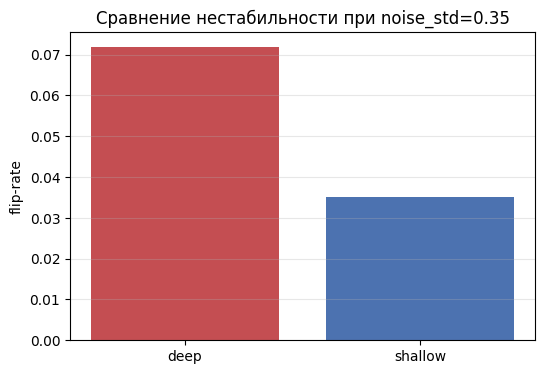

In [6]:
NOISE_COMPARE = 0.35
flip_at = {
    'deep': flip_rate(tree_deep, X_val, NOISE_COMPARE),
    'shallow': flip_rate(tree_shallow, X_val, NOISE_COMPARE),
}

print('flip-rate @', NOISE_COMPARE, '→', {k: round(v, 3) for k, v in flip_at.items()})
print('val accuracy deep/shallow:', round(acc_deep, 3), round(acc_shallow, 3))

plt.figure(figsize=(6, 4))
plt.bar(list(flip_at.keys()), list(flip_at.values()), color=['#c44e52', '#4c72b0'])
plt.ylabel('flip-rate')
plt.title(f'Сравнение нестабильности при noise_std={NOISE_COMPARE}')
plt.grid(axis='y', alpha=0.3)
plt.show()


---
## Задание 6. `plot_tree` устойчивого варианта — **3 балла**

Покажите, что **простые правила** читаются глазом.

**Шаг 1.** Нарисуйте `plot_tree` для `tree_shallow` (устойчивее по flip-rate).
Используйте `feature_names=FEATURE_NAMES`, `class_names=CLASS_NAMES`, `filled=True`.
Подберите `figsize`, чтобы дерево читалось.

**Шаг 2.** Одним предложением (print/markdown): почему короткое дерево обычно спокойнее реагирует на шум признаков?

### Подробные критерии (для проверки LLM)

- **2.0 балла** — построен `plot_tree` для ограниченного дерева с именами признаков и классов.
- **1.0 балл** — есть объяснение связи «мало листьев / короткие правила → устойчивее к мелкому шуму».

### Снижение баллов

- Нарисовано только глубокое дерево без shallow → минус **1.0**.
- Нет `feature_names` / `class_names` → минус **0.5**.


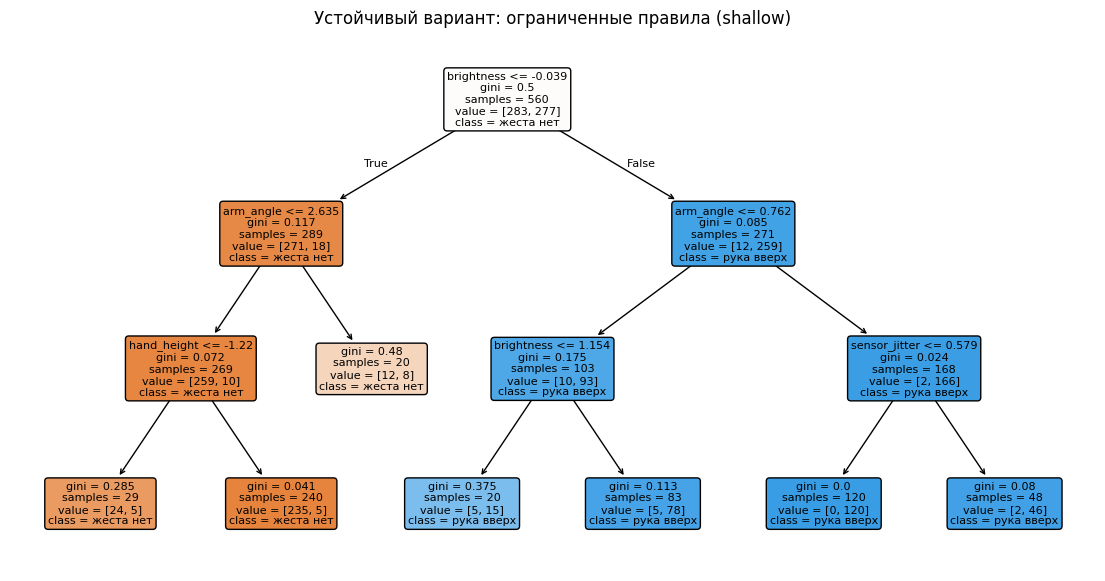

Короткие правила реже цепляются за случайные пороги на шумных признаках: мелкий гауссов шум реже перебрасывает объект через границу листа.


In [7]:
plt.figure(figsize=(14, 7))
plot_tree(
    tree_shallow,
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title('Устойчивый вариант: ограниченные правила (shallow)')
plt.show()

print(
    'Короткие правила реже цепляются за случайные пороги на шумных признаках: '
    'мелкий гауссов шум реже перебрасывает объект через границу листа.'
)


---
## Задание 7. `ccp_alpha` через стабильность — **4 балла**

Обрезка дерева (`ccp_alpha`) — ещё один способ сделать правила проще.
Здесь смотрим на неё **через flip-rate**, а не через «найди лучший score».

**Шаг 1.** Для нескольких значений, например `alphas = [0.0, 0.005, 0.01, 0.02]`:
- обучите `DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE)` на train;
- запишите число листьев, validation accuracy и flip-rate при `NOISE_COMPARE`.

**Шаг 2.** Постройте график: по оси X — `ccp_alpha`, по оси Y — flip-rate (линия с маркерами).
Заголовок и подписи осей обязательны; число листьев можно напечатать таблицей рядом.

**Шаг 3.** Выберите `tree_stable` — модель с **низким** flip-rate среди разумных вариантов
(не обязательно максимальный accuracy; главное — стабильность без совсем «обрубленного» дерева из одного вопроса, если оно явно хуже по смыслу).
Кратко поясните выбор.

### Подробные критерии (для проверки LLM)

- **1.5 балла** — таблица/печать: alpha → листья, val accuracy, flip-rate.
- **1.5 балла** — график flip-rate vs `ccp_alpha` с заголовком и осями.
- **1.0 балл** — выбран `tree_stable` с явным обоснованием через стабильность.

### Снижение баллов

- Выбор только по максимальному accuracy без взгляда на flip-rate → минус **1.0**.
- Нет графика → минус **1.0**.


 ccp_alpha  leaves  depth  val_acc     flip
     0.000      29      9 0.945833 0.071875
     0.005       7      4 0.962500 0.034792
     0.010       3      2 0.958333 0.036250
     0.020       2      1 0.950000 0.035000


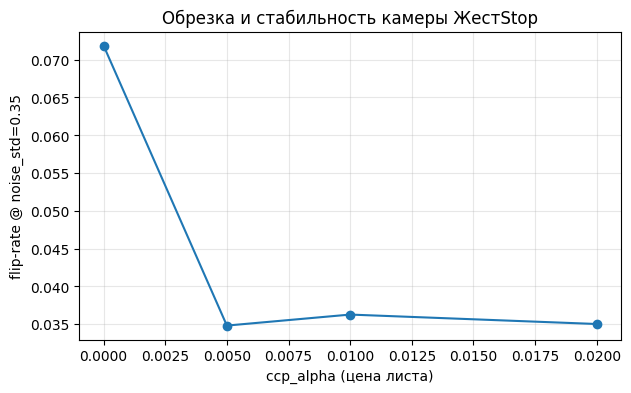

tree_stable: ccp_alpha=0.005, leaves= 7 , flip= 0.035 — проще глубокого, стабильнее, правила ещё читаются.


In [8]:
alphas = [0.0, 0.005, 0.01, 0.02]
rows = []
models_by_alpha = {}

for alpha in alphas:
    model = DecisionTreeClassifier(ccp_alpha=alpha, random_state=RANDOM_STATE).fit(X_train, y_train)
    models_by_alpha[alpha] = model
    rows.append({
        'ccp_alpha': alpha,
        'leaves': model.get_n_leaves(),
        'depth': model.get_depth(),
        'val_acc': accuracy_score(y_val, model.predict(X_val)),
        'flip': flip_rate(model, X_val, NOISE_COMPARE),
    })

df_prune = pd.DataFrame(rows)
print(df_prune.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.plot(df_prune['ccp_alpha'], df_prune['flip'], marker='o')
plt.xlabel('ccp_alpha (цена листа)')
plt.ylabel(f'flip-rate @ noise_std={NOISE_COMPARE}')
plt.title('Обрезка и стабильность камеры ЖестStop')
plt.grid(alpha=0.3)
plt.show()

# Берём обрезку с низким flip-rate и ещё несколькими листьями (не один вопрос).
tree_stable = models_by_alpha[0.005]
print(
    'tree_stable: ccp_alpha=0.005, leaves=', tree_stable.get_n_leaves(),
    ', flip=', round(flip_rate(tree_stable, X_val, NOISE_COMPARE), 3),
    '— проще глубокого, стабильнее, правила ещё читаются.'
)


---
## Задание 8. Confusion matrix (доп. взгляд) — **2 балла**

Матрица ошибок — **дополнительный** взгляд: стабильность мы уже измерили flip-rate.
Здесь просто посмотрите, где ошибается устойчивая модель на чистом validation.

**Шаг 1.** Для `tree_stable` (или `tree_shallow`, если stable не выбран) постройте heatmap матрицы ошибок
(`ConfusionMatrixDisplay` или `imshow` — на ваш вкус).

**Шаг 2.** Подпишите классы через `CLASS_NAMES`. Заголовок обязателен.

**Шаг 3.** Одной фразой: confusion показывает *какие* ошибки, flip-rate — *как часто ответ прыгает* при шуме.

### Подробные критерии (для проверки LLM)

- **1.5 балла** — heatmap confusion на validation для устойчивой модели, с подписями классов.
- **0.5 балла** — есть фраза про разный смысл confusion vs flip-rate.

### Снижение баллов

- Нет заголовка / подписей → минус **0.5**.
- Считается только на train → минус **1.0**.


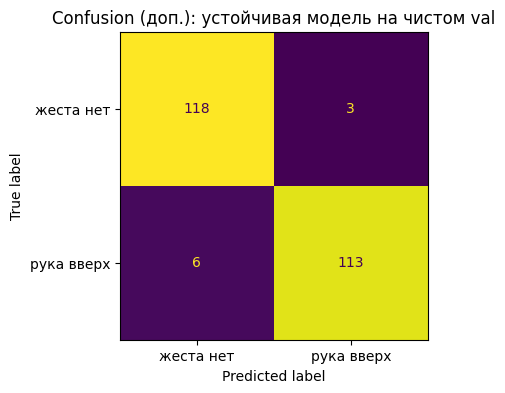

Confusion отвечает на вопрос «какие ошибки на спокойных кадрах»; flip-rate — «как часто ответ прыгает, когда кадр чуть зашумили».


In [9]:
y_pred_stable = tree_stable.predict(X_val)
cm = confusion_matrix(y_val, y_pred_stable)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(ax=ax, colorbar=False)
ax.set_title('Confusion (доп.): устойчивая модель на чистом val')
plt.show()

print(
    'Confusion отвечает на вопрос «какие ошибки на спокойных кадрах»; '
    'flip-rate — «как часто ответ прыгает, когда кадр чуть зашумили».'
)


---
## Задание 9. Итог: почему глубокое дерево «нервное» — **2 балла**

Сформулируйте **три** коротких вывода по **своим числам** (не общие определения):

1. Что показали flip-rate deep vs shallow (и bar / кривая)?
2. Как связаны глубина / число листьев / `ccp_alpha` со стабильностью?
3. Почему для камеры «ЖестStop» опаснее «нервное» дерево, даже если accuracy почти как у спокойного?

### Подробные критерии (для проверки LLM)

- **0.7 балла** — вывод с числами flip-rate deep vs shallow.
- **0.7 балла** — связь сложности дерева (глубина/листья/обрезка) и стабильности.
- **0.6 балла** — прикладной смысл для камеры / дрожащих предсказаний.

### Снижение баллов

- Выводы без опоры на графики/числа практики → минус **0.5**.


**Итоговые выводы (авторский вариант):**

1. **Flip-rate:** при `noise_std=0.35` глубокое дерево меняет ответы заметно чаще ограниченного (порядка **~0.07 vs ~0.035** на нашей генерации) — кривая deep выше на всём диапазоне шума, bar это подтверждает. При этом validation accuracy у обеих моделей близка (~0.95).
2. **Сложность ↔ стабильность:** больше глубина и листьев → мельче области решений → легче «перепрыгнуть» порог из‑за шума. `max_depth` / `min_samples_leaf` и умеренный `ccp_alpha` упрощают правила и снижают flip-rate.
3. **Для камеры:** даже при похожей accuracy «нервное» дерево будет то включать, то выключать жест на почти том же кадре (блик, тряска). На улице важны **спокойные** правила, а не идеальная подгонка train.
